# TPSF / IRF Result Explorer

Pick a **TPSF** folder and an **IRF** folder below, then run the notebook top to bottom.

1. Load the gate (instrument) profile used as the deconvolution kernel
2. Load TPSF / load IRF
3. Deconvolve **both** TPSF and IRF (Richardson-Lucy, same gate kernel)
4. Save each panel as its own PNG (TPSF-only, IRF-only, and combined versions of raw / deconvolved / MSE / FWHM) so they can be assembled into the three LaTeX figures below
5. Peak-to-peak time difference (deconvolved TPSF vs deconvolved IRF) and the equivalent path difference in air

No plot has a title — each plot is preceded by a print statement describing what it shows.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.interpolate import interp1d
from skimage.restoration import richardson_lucy

plt.rcParams.update({
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

# Speed of light in air (mm/ps). Using vacuum c and n_air ~ 1.0003 (negligible correction).
C_MM_PER_PS = 0.299792458 / 1.0003


def compute_fwhm(signal, time_vec):
    """Robust FWHM calculation."""
    signal = np.asarray(signal, dtype=float)
    half_max = np.max(signal) / 2
    indices_above_half = np.where(signal >= half_max)[0]
    if len(indices_above_half) < 2:
        return np.nan
    left_idx = indices_above_half[0]
    right_idx = indices_above_half[-1]
    return time_vec[right_idx] - time_vec[left_idx]


def load_trace_folder(folder):
    """Load t_axis / raw_counts from a result folder."""
    folder = Path(folder)
    t_axis = np.load(folder / "t_axis.npy")
    raw_counts = np.load(folder / "raw_counts.npy")
    return {"folder": folder, "t_axis": t_axis, "raw_counts": raw_counts}


def deconvolve_trace(t_axis, raw_counts, gate_profile, max_iterations=500, step_iterations=5):
    """Richardson-Lucy deconvolution with MSE/FWHM tracking, returns dict of results."""
    mse_history, fwhm_history, iteration_nums = [], [], []
    for num_iter in range(1, max_iterations + 1, step_iterations):
        deconv_temp = richardson_lucy(raw_counts, gate_profile, num_iter=num_iter, clip=False)
        deconv_temp *= np.sum(raw_counts) / np.sum(deconv_temp)  # preserve total signal

        reconv_temp = np.convolve(deconv_temp, gate_profile, mode="same")
        mse = np.mean((raw_counts - reconv_temp) ** 2)

        mse_history.append(mse)
        fwhm_history.append(compute_fwhm(deconv_temp, t_axis))
        iteration_nums.append(num_iter)

    best_iter = iteration_nums[int(np.argmin(mse_history))]

    deconvolved = richardson_lucy(raw_counts, gate_profile, num_iter=best_iter, clip=False)
    deconvolved *= np.sum(raw_counts) / np.sum(deconvolved)
    reconvolved = np.convolve(deconvolved, gate_profile, mode="same")

    return {
        "deconvolved": deconvolved,
        "reconvolved": reconvolved,
        "best_iter": best_iter,
        "mse_history": np.array(mse_history),
        "fwhm_history": np.array(fwhm_history),
        "iteration_nums": np.array(iteration_nums),
    }


def deconvolve_at_iteration(raw_counts, gate_profile, num_iter):
    """Run Richardson-Lucy for a fixed number of iterations (for intermediate snapshots)."""
    deconv = richardson_lucy(raw_counts, gate_profile, num_iter=num_iter, clip=False)
    deconv *= np.sum(raw_counts) / np.sum(deconv)
    return deconv


In [36]:
# -------- Load the gate/instrument profile (shared deconvolution kernel) --------
gate_csv_path = Path(r"D:\Shira_TZ_ISCOS\Gate_SPAD_6ns.csv")  # Change this to your gate CSV path

gate_df = pd.read_csv(gate_csv_path)

# Flip gate and time axis
gate_df.iloc[:, 0] = -gate_df.iloc[:, 0][::-1].reset_index(drop=True)
gate_df.iloc[:, 1] = gate_df.iloc[:, 1][::-1].reset_index(drop=True)

gate_interp_func = interp1d(
    gate_df.iloc[:, 0], gate_df.iloc[:, 1], kind="linear", bounds_error=False, fill_value=0
)

print(f"Loaded gate profile from {gate_csv_path.name}")
print(f"  {len(gate_df)} raw gate samples, time range [{gate_df.iloc[:,0].min():.2f}, {gate_df.iloc[:,0].max():.2f}] ns")


def build_gate_profile(t_axis_ps):
    """Interpolate the gate profile onto a given (ps) time axis and normalize it."""
    time_step_ps = np.mean(np.diff(t_axis_ps))
    t_limit_ps = max(abs(gate_df.iloc[:, 0].min() * 1000), abs(gate_df.iloc[:, 0].max() * 1000))
    time_vec_gate_ps = np.arange(-t_limit_ps, t_limit_ps, time_step_ps)
    profile = gate_interp_func(time_vec_gate_ps / 1000)
    return profile / np.sum(profile)


Loaded gate profile from Gate_SPAD_6ns.csv
  238 raw gate samples, time range [-8.29, 0.72] ns


In [37]:
# -------- Select TPSF folder --------
tpsf_folder = Path(r"D:\Shira_TZ_ISCOS\19-04-2026 Gated and PaLS-iSCOS 1cmSDS 10bit with Pileup\TPSF_1776597076")  # Change this

tpsf = load_trace_folder(tpsf_folder)

print(f"Loaded TPSF from {tpsf['folder'].name}")
print(f"  Time points: {len(tpsf['t_axis'])}")
print(f"  Time range: {tpsf['t_axis'][0]:.1f} to {tpsf['t_axis'][-1]:.1f} ps")
print(f"  Peak raw counts: {np.max(tpsf['raw_counts']):.0f}")


Loaded TPSF from TPSF_1776597076
  Time points: 968
  Time range: 28315.2 to 46301.4 ps
  Peak raw counts: 46


In [38]:
# -------- Select IRF folder --------
irf_folder = Path(r"D:\Shira_TZ_ISCOS\19-04-2026 Gated and PaLS-iSCOS 1cmSDS 10bit with Pileup\ref-5\IRF_1776600783")  # Change this

irf = load_trace_folder(irf_folder)

print(f"Loaded IRF from {irf['folder'].name}")
print(f"  Time points: {len(irf['t_axis'])}")
print(f"  Time range: {irf['t_axis'][0]:.1f} to {irf['t_axis'][-1]:.1f} ps")
print(f"  Peak raw counts: {np.max(irf['raw_counts']):.0f}")


Loaded IRF from IRF_1776600783
  Time points: 968
  Time range: 28278.0 to 46264.2 ps
  Peak raw counts: 269


In [39]:
# -------- Deconvolve both TPSF and IRF with the same gate kernel --------
max_iterations = 500
step_iterations = 5

tpsf_gate_profile = build_gate_profile(tpsf["t_axis"])
irf_gate_profile = build_gate_profile(irf["t_axis"])

tpsf_result = deconvolve_trace(
    tpsf["t_axis"], tpsf["raw_counts"], tpsf_gate_profile, max_iterations, step_iterations
)
irf_result = deconvolve_trace(
    irf["t_axis"], irf["raw_counts"], irf_gate_profile, max_iterations, step_iterations
)

print("TPSF deconvolution:")
print(f"  Best iteration: {tpsf_result['best_iter']} (MSE: {tpsf_result['mse_history'].min():.2e})")
print(f"  Deconvolved FWHM: {compute_fwhm(tpsf_result['deconvolved'], tpsf['t_axis']):.1f} ps")

print("\nIRF deconvolution:")
print(f"  Best iteration: {irf_result['best_iter']} (MSE: {irf_result['mse_history'].min():.2e})")
print(f"  Deconvolved FWHM: {compute_fwhm(irf_result['deconvolved'], irf['t_axis']):.1f} ps")


TPSF deconvolution:
  Best iteration: 141 (MSE: 2.24e+00)
  Deconvolved FWHM: 446.4 ps

IRF deconvolution:
  Best iteration: 166 (MSE: 1.43e+02)
  Deconvolved FWHM: 372.0 ps


In [40]:
# -------- Figure output --------
# Folder used in the LaTeX \includegraphics paths below (e.g. TPSF/raw_tpsf.png)
fig_dir = Path("TPSF")
fig_dir.mkdir(parents=True, exist_ok=True)

PANEL_FIGSIZE = (5, 4)


def save_panel(fig, name):
    out_path = fig_dir / f"{name}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"  saved: {out_path}")


Plot: Raw TPSF
  saved: TPSF\raw_tpsf.png


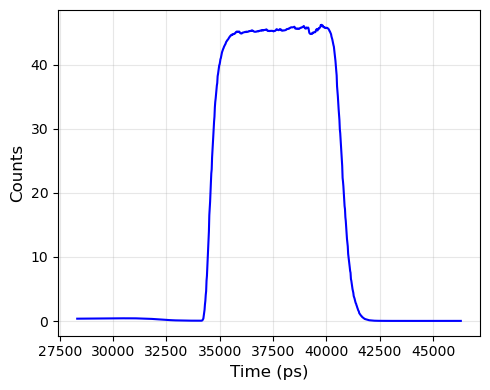


Plot: Raw IRF
  saved: TPSF\raw_irf.png


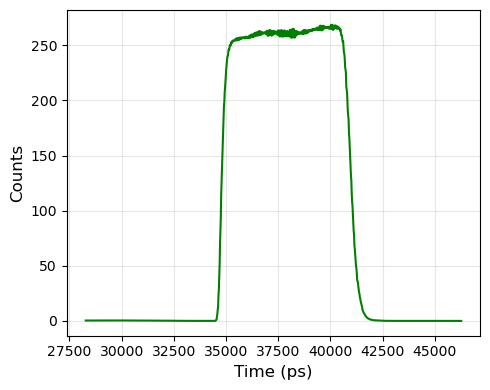


Plot: Raw TPSF vs Raw IRF (combined, normalized)
  saved: TPSF\raw_combined.png


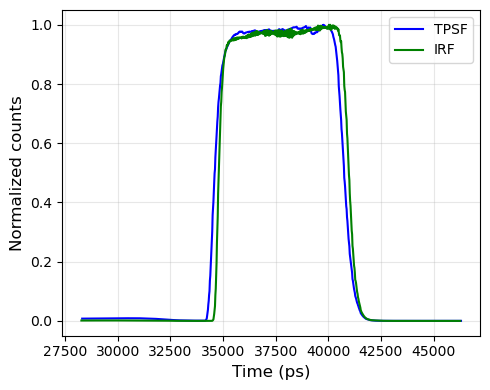

In [41]:
# --- Panel: Raw TPSF ---
print("Plot: Raw TPSF")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf["raw_counts"], "b-", linewidth=1.5)
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Counts")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "raw_tpsf")
plt.show()

# --- Panel: Raw IRF ---
print("\nPlot: Raw IRF")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(irf["t_axis"], irf["raw_counts"], "g-", linewidth=1.5)
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Counts")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "raw_irf")
plt.show()

# --- Panel: Raw TPSF vs Raw IRF (combined, normalized) ---
print("\nPlot: Raw TPSF vs Raw IRF (combined, normalized)")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf["raw_counts"] / np.max(tpsf["raw_counts"]), "b-", linewidth=1.5, label="TPSF")
ax.plot(irf["t_axis"], irf["raw_counts"] / np.max(irf["raw_counts"]), "g-", linewidth=1.5, label="IRF")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Normalized counts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "raw_combined")
plt.show()


Intermediate TPSF snapshot at iteration 36 (best iteration is 141)

Plot: Deconvolved TPSF, final (FWHM: 446.4 ps, iterations: 141)
  saved: TPSF\deconv_tpsf.png


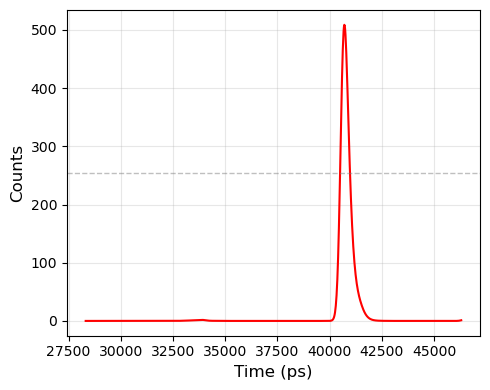


Plot: Deconvolved TPSF at iteration 36 (FWHM: 725.4 ps)
  saved: TPSF\deconv_tpsf_mid.png


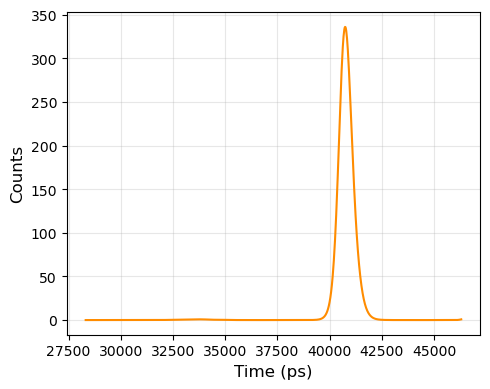


Plot: Deconvolved IRF, final (FWHM: 372.0 ps, iterations: 166)
  saved: TPSF\deconv_irf.png


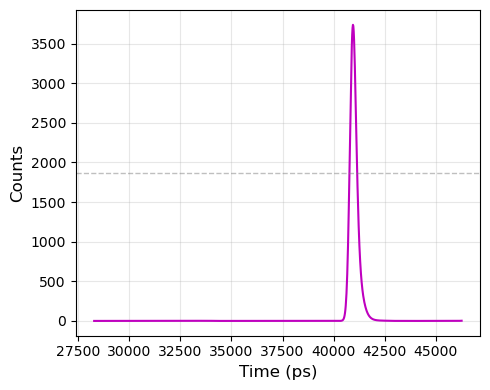


Plot: Deconvolved TPSF vs Deconvolved IRF (combined, normalized)
  saved: TPSF\deconv_combined.png


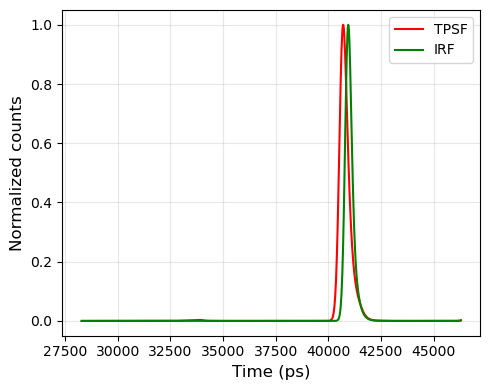

In [ ]:
# -------- Intermediate TPSF deconvolution snapshot (for the profile-effect figure) --------
# Pick an early iteration count, snapped to the nearest computed step
intermediate_iter = max(step_iterations, tpsf_result["best_iter"] // 4)
intermediate_iter = int(tpsf_result["iteration_nums"][np.argmin(np.abs(tpsf_result["iteration_nums"] - intermediate_iter))])
tpsf_deconv_mid = deconvolve_at_iteration(tpsf["raw_counts"], tpsf_gate_profile, intermediate_iter)
print(f"Intermediate TPSF snapshot at iteration {intermediate_iter} (best iteration is {tpsf_result['best_iter']})")

# --- Panel: Deconvolved TPSF (final, best iteration) ---
print(f"\nPlot: Deconvolved TPSF, final (FWHM: {compute_fwhm(tpsf_result['deconvolved'], tpsf['t_axis']):.1f} ps, iterations: {tpsf_result['best_iter']})")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf_result["deconvolved"], "r-", linewidth=1.5)
half_max = np.max(tpsf_result["deconvolved"]) / 2
ax.axhline(half_max, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Counts")
ax.grid(True, alpha=0.3)

tpsf_nonzero_indices = np.where(tpsf_result["deconvolved"] > 0.01*np.max(tpsf_result["deconvolved"]))[0]
plot_start_idx = tpsf_nonzero_indices[0]
plot_end_idx = tpsf_nonzero_indices[-1]
ax.set_xlim(tpsf["t_axis"][plot_start_idx], tpsf["t_axis"][plot_end_idx])
plt.tight_layout()
save_panel(fig, "deconv_tpsf")
plt.show()

# --- Panel: Deconvolved TPSF, intermediate iteration ---
print(f"\nPlot: Deconvolved TPSF at iteration {intermediate_iter} (FWHM: {compute_fwhm(tpsf_deconv_mid, tpsf['t_axis']):.1f} ps)")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf_deconv_mid, "darkorange", linewidth=1.5)
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Counts")
ax.grid(True, alpha=0.3)
ax.set_xlim(tpsf["t_axis"][plot_start_idx], tpsf["t_axis"][plot_end_idx])
plt.tight_layout()
save_panel(fig, "deconv_tpsf_mid")
plt.show()

# --- Panel: Deconvolved IRF (final) ---
print(f"\nPlot: Deconvolved IRF, final (FWHM: {compute_fwhm(irf_result['deconvolved'], irf['t_axis']):.1f} ps, iterations: {irf_result['best_iter']})")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(irf["t_axis"], irf_result["deconvolved"], "m-", linewidth=1.5)
half_max = np.max(irf_result["deconvolved"]) / 2
ax.axhline(half_max, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Counts")
ax.grid(True, alpha=0.3)
ax.set_xlim(tpsf["t_axis"][plot_start_idx], tpsf["t_axis"][plot_end_idx])
plt.tight_layout()
save_panel(fig, "deconv_irf")
plt.show()

# --- Panel: Deconvolved TPSF vs Deconvolved IRF (combined, normalized) ---
print("\nPlot: Deconvolved TPSF vs Deconvolved IRF (combined, normalized)")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf_result["deconvolved"] / np.max(tpsf_result["deconvolved"]), "r-", linewidth=1.5, label="TPSF")
ax.plot(irf["t_axis"], irf_result["deconvolved"] / np.max(irf_result["deconvolved"]), "g-", linewidth=1.5, label="IRF")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Normalized counts")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(tpsf["t_axis"][plot_start_idx], tpsf["t_axis"][plot_end_idx])
plt.tight_layout()
save_panel(fig, "deconv_combined")
plt.show()


Plot: Raw vs deconvolved TPSF (FWHM: 446.4 ps, iterations: 141)
  saved: TPSF\raw_deconv_tpsf.png


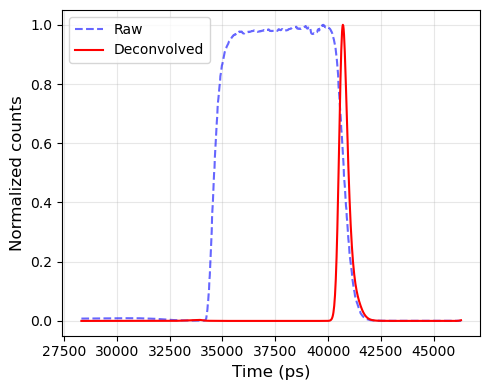


Plot: Raw vs deconvolved IRF (FWHM: 372.0 ps, iterations: 166)
  saved: TPSF\raw_deconv_irf.png


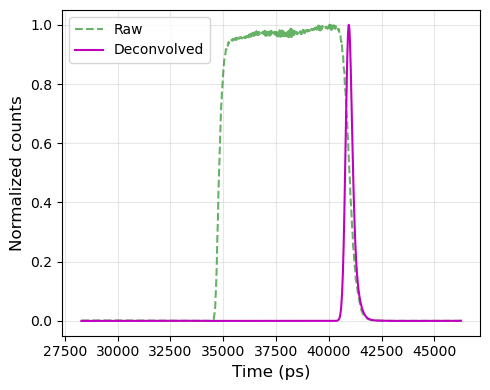

In [43]:
# --- Panel: Raw vs Deconvolved TPSF (same trace, overlaid, normalized) ---
print(f"Plot: Raw vs deconvolved TPSF (FWHM: {compute_fwhm(tpsf_result['deconvolved'], tpsf['t_axis']):.1f} ps, iterations: {tpsf_result['best_iter']})")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf["raw_counts"] / np.max(tpsf["raw_counts"]), "b--", linewidth=1.5, alpha=0.6, label="Raw")
ax.plot(tpsf["t_axis"], tpsf_result["deconvolved"] / np.max(tpsf_result["deconvolved"]), "r-", linewidth=1.5, label="Deconvolved")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Normalized counts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "raw_deconv_tpsf")
plt.show()

# --- Panel: Raw vs Deconvolved IRF (same trace, overlaid, normalized) ---
print(f"\nPlot: Raw vs deconvolved IRF (FWHM: {compute_fwhm(irf_result['deconvolved'], irf['t_axis']):.1f} ps, iterations: {irf_result['best_iter']})")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(irf["t_axis"], irf["raw_counts"] / np.max(irf["raw_counts"]), "g--", linewidth=1.5, alpha=0.6, label="Raw")
ax.plot(irf["t_axis"], irf_result["deconvolved"] / np.max(irf_result["deconvolved"]), "m-", linewidth=1.5, label="Deconvolved")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Normalized counts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "raw_deconv_irf")
plt.show()


Plot: TPSF reconvolution quality check (MSE: 2.24e+00)
  saved: TPSF\reconv_tpsf.png


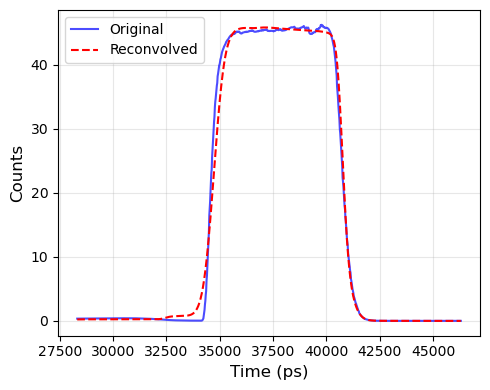


Plot: IRF reconvolution quality check (MSE: 1.43e+02)
  saved: TPSF\reconv_irf.png


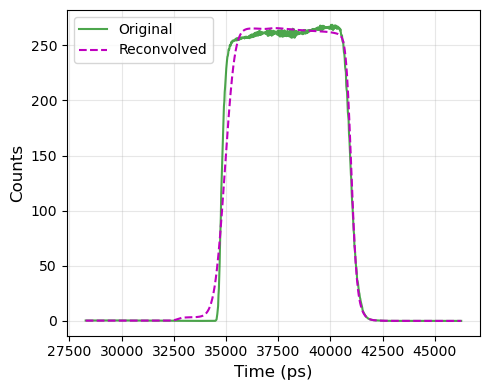

In [44]:
# --- Panel: Reconvolved TPSF (original vs reconvolved) ---
tpsf_final_mse = np.mean((tpsf["raw_counts"] - tpsf_result["reconvolved"]) ** 2)
print(f"Plot: TPSF reconvolution quality check (MSE: {tpsf_final_mse:.2e})")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf["raw_counts"], "b-", linewidth=1.5, label="Original", alpha=0.7)
ax.plot(tpsf["t_axis"], tpsf_result["reconvolved"], "r--", linewidth=1.5, label="Reconvolved")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Counts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "reconv_tpsf")
plt.show()

# --- Panel: Reconvolved IRF (original vs reconvolved) ---
irf_final_mse = np.mean((irf["raw_counts"] - irf_result["reconvolved"]) ** 2)
print(f"\nPlot: IRF reconvolution quality check (MSE: {irf_final_mse:.2e})")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(irf["t_axis"], irf["raw_counts"], "g-", linewidth=1.5, label="Original", alpha=0.7)
ax.plot(irf["t_axis"], irf_result["reconvolved"], "m--", linewidth=1.5, label="Reconvolved")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Counts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "reconv_irf")
plt.show()


Plot: MSE vs iteration, TPSF only, log scale
  saved: TPSF\mse_tpsf.png


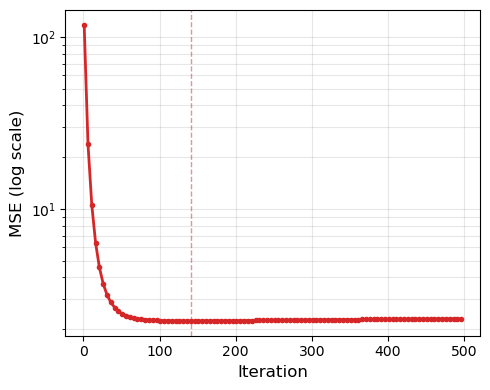


Plot: MSE vs iteration, IRF only, log scale
  saved: TPSF\mse_irf.png


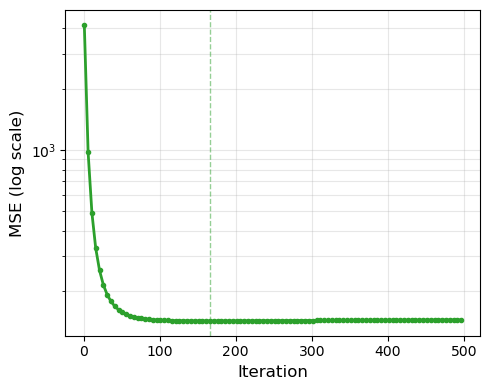


Plot: MSE vs iteration, TPSF and IRF combined, log scale
  saved: TPSF\mse_combined.png


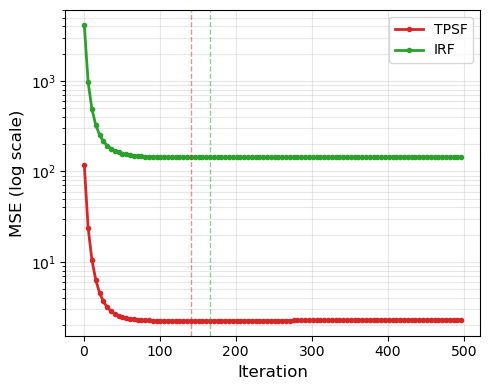

In [45]:
# --- Panel: MSE vs iteration, TPSF only (log scale) ---
print("Plot: MSE vs iteration, TPSF only, log scale")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.semilogy(tpsf_result["iteration_nums"], tpsf_result["mse_history"], "o-", color="tab:red", linewidth=2, markersize=3)
ax.axvline(tpsf_result["best_iter"], color="tab:red", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE (log scale)")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
save_panel(fig, "mse_tpsf")
plt.show()

# --- Panel: MSE vs iteration, IRF only (log scale) ---
print("\nPlot: MSE vs iteration, IRF only, log scale")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.semilogy(irf_result["iteration_nums"], irf_result["mse_history"], "o-", color="tab:green", linewidth=2, markersize=3)
ax.axvline(irf_result["best_iter"], color="tab:green", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE (log scale)")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
save_panel(fig, "mse_irf")
plt.show()

# --- Panel: MSE vs iteration, TPSF and IRF combined (log scale) ---
print("\nPlot: MSE vs iteration, TPSF and IRF combined, log scale")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.semilogy(tpsf_result["iteration_nums"], tpsf_result["mse_history"], "o-", color="tab:red",
            linewidth=2, markersize=3, label="TPSF")
ax.semilogy(irf_result["iteration_nums"], irf_result["mse_history"], "o-", color="tab:green",
            linewidth=2, markersize=3, label="IRF")
ax.axvline(tpsf_result["best_iter"], color="tab:red", linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(irf_result["best_iter"], color="tab:green", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE (log scale)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
save_panel(fig, "mse_combined")
plt.show()


Plot: FWHM vs iteration, TPSF only, log scale
  saved: TPSF\fwhm_tpsf.png


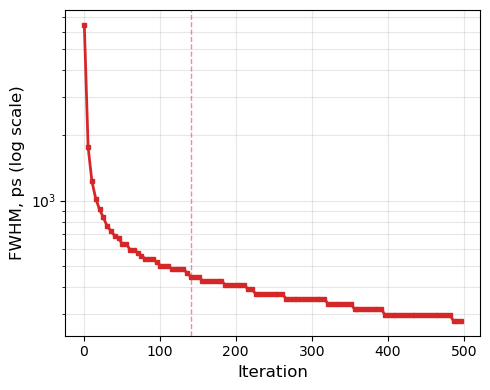


Plot: FWHM vs iteration, IRF only, log scale
  saved: TPSF\fwhm_irf.png


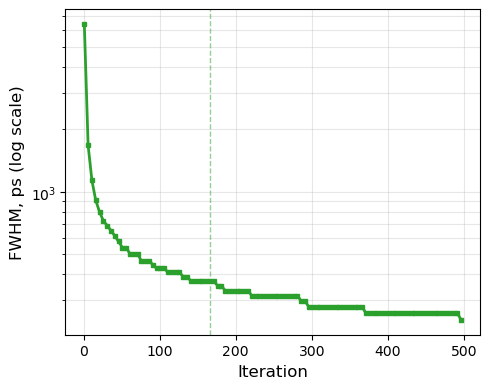


Plot: FWHM vs iteration, TPSF and IRF combined, log scale
  saved: TPSF\fwhm_combined.png


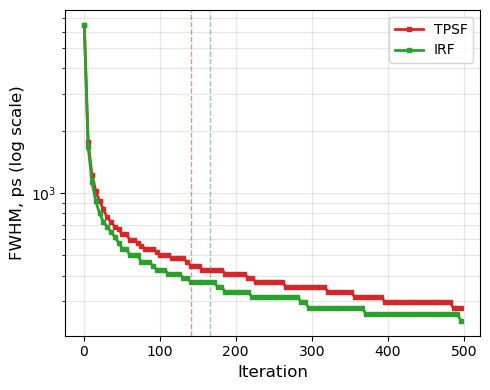

In [46]:
# --- Panel: FWHM vs iteration, TPSF only (log scale) ---
print("Plot: FWHM vs iteration, TPSF only, log scale")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.semilogy(tpsf_result["iteration_nums"], tpsf_result["fwhm_history"], "s-", color="tab:red", linewidth=2, markersize=3)
ax.axvline(tpsf_result["best_iter"], color="tab:red", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("FWHM, ps (log scale)")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
save_panel(fig, "fwhm_tpsf")
plt.show()

# --- Panel: FWHM vs iteration, IRF only (log scale) ---
print("\nPlot: FWHM vs iteration, IRF only, log scale")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.semilogy(irf_result["iteration_nums"], irf_result["fwhm_history"], "s-", color="tab:green", linewidth=2, markersize=3)
ax.axvline(irf_result["best_iter"], color="tab:green", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("FWHM, ps (log scale)")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
save_panel(fig, "fwhm_irf")
plt.show()

# --- Panel: FWHM vs iteration, TPSF and IRF combined (log scale) ---
print("\nPlot: FWHM vs iteration, TPSF and IRF combined, log scale")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.semilogy(tpsf_result["iteration_nums"], tpsf_result["fwhm_history"], "s-", color="tab:red",
            linewidth=2, markersize=3, label="TPSF")
ax.semilogy(irf_result["iteration_nums"], irf_result["fwhm_history"], "s-", color="tab:green",
            linewidth=2, markersize=3, label="IRF")
ax.axvline(tpsf_result["best_iter"], color="tab:red", linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(irf_result["best_iter"], color="tab:green", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("FWHM, ps (log scale)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
save_panel(fig, "fwhm_combined")
plt.show()


Deconvolved TPSF peak time: 40702.8 ps
Deconvolved IRF peak time:  40944.6 ps
Time difference (TPSF - IRF): -241.8 ps
Equivalent path difference in air: -72.47 mm (-7.247 cm)

Plot: Deconvolved TPSF and deconvolved IRF, peak markers, time/path difference
  saved: TPSF\position_diff.png


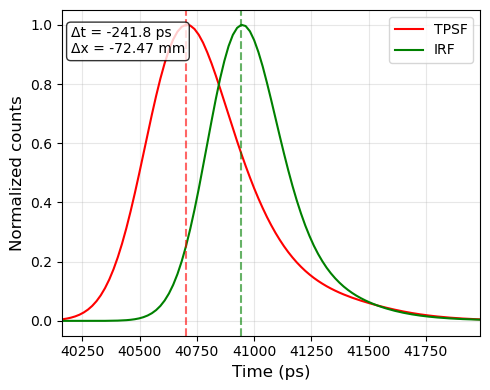

In [47]:
# -------- Peak-to-peak time difference & path difference in air --------
# Uses the DECONVOLVED TPSF and DECONVOLVED IRF (both already gate-deconvolved above)
tpsf_peak_idx = np.argmax(tpsf_result["deconvolved"])
tpsf_peak_time_ps = tpsf["t_axis"][tpsf_peak_idx]

irf_peak_idx = np.argmax(irf_result["deconvolved"])
irf_peak_time_ps = irf["t_axis"][irf_peak_idx]

time_diff_ps = tpsf_peak_time_ps - irf_peak_time_ps
path_diff_mm = C_MM_PER_PS * time_diff_ps
path_diff_cm = path_diff_mm / 10.0

print(f"Deconvolved TPSF peak time: {tpsf_peak_time_ps:.1f} ps")
print(f"Deconvolved IRF peak time:  {irf_peak_time_ps:.1f} ps")
print(f"Time difference (TPSF - IRF): {time_diff_ps:.1f} ps")
print(f"Equivalent path difference in air: {path_diff_mm:.2f} mm ({path_diff_cm:.3f} cm)")

# --- Panel: deconvolved TPSF and IRF with peak markers and time/path difference ---
print("\nPlot: Deconvolved TPSF and deconvolved IRF, peak markers, time/path difference")
fig, ax = plt.subplots(figsize=PANEL_FIGSIZE)
ax.plot(tpsf["t_axis"], tpsf_result["deconvolved"] / np.max(tpsf_result["deconvolved"]), "r-", linewidth=1.5, label="TPSF")
ax.plot(irf["t_axis"], irf_result["deconvolved"] / np.max(irf_result["deconvolved"]), "g-", linewidth=1.5, label="IRF")
ax.axvline(tpsf_peak_time_ps, color="r", linestyle="--", alpha=0.6)
ax.axvline(irf_peak_time_ps, color="g", linestyle="--", alpha=0.6)
ax.annotate(
    f"\u0394t = {time_diff_ps:.1f} ps\n\u0394x = {path_diff_mm:.2f} mm",
    xy=(0.02, 0.95), xycoords="axes fraction", va="top", ha="left",
    fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8),
)

tpsf_nonzero_indices = np.where(tpsf_result["deconvolved"] > 0.005*np.max(tpsf_result["deconvolved"]))[0]
irf_nonzero_indices = np.where(irf_result["deconvolved"] > 0.005*np.max(irf_result["deconvolved"]))[0]
plot_start_idx = min(tpsf_nonzero_indices[0], irf_nonzero_indices[0])
plot_end_idx = max(tpsf_nonzero_indices[-1], irf_nonzero_indices[-1])
ax.set_xlim(tpsf["t_axis"][plot_start_idx], tpsf["t_axis"][plot_end_idx])



ax.set_xlabel("Time (ps)")
ax.set_ylabel("Normalized counts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_panel(fig, "position_diff")
plt.show()


In [48]:
# -------- Summary of saved panels --------
print(f"All panels saved to: {fig_dir.resolve()}\n")
for f in sorted(fig_dir.glob("*.png")):
    print(" ", f.name)


All panels saved to: C:\Users\Shira\OneDrive - Bar-Ilan University - Students\Lab\Python Files\PaLS-iSCOS_Project\Open_Results\TPSF

  deconv_combined.png
  deconv_irf.png
  deconv_tpsf.png
  deconv_tpsf_mid.png
  fwhm_combined.png
  fwhm_irf.png
  fwhm_tpsf.png
  mse_combined.png
  mse_irf.png
  mse_tpsf.png
  position_diff.png
  raw_combined.png
  raw_deconv_irf.png
  raw_deconv_tpsf.png
  raw_irf.png
  raw_tpsf.png
  reconv_irf.png
  reconv_tpsf.png
